# Part 1 -- Data Scaling Law on DarijaDZ

Companion notebook to `../scaling_laws_lab.md` Part 1. **Deviations from the lab doc's
original suggestions, each deliberate and logged here rather than made silently:**

1. **Tokenizer: `unigram_20000`, not `bpe_10000`.** This is the exact SentencePiece
   Unigram tokenizer `Embeddings/word2vec/skip-gram`'s reused embedding checkpoint was
   trained against (`Tokenization/models_bigcorpus/sentencepiece/unigram_20000.model` --
   note the `_bigcorpus` tree, not the default `Tokenization/models/`). Using any other
   tokenizer would make that checkpoint's vocabulary ids meaningless as an initialization.
2. **`d_model=128`** (not the lab doc's suggested `128` for a *different* model -- this
   still matches, but for a different reason: it's also word2vec's `embed_dim`, so the
   reused embedding matrices plug in with no projection needed).
3. **Embeddings are NOT tied** (unlike `LM_DiD/scripts/model.py`, which this model is
   otherwise adapted from) -- kept as two separate matrices specifically so
   `tok_embedding` can be initialized from word2vec's `input_embeddings` and `lm_head`
   from its `output_embeddings` independently.
4. **Subsets stop at 10M tokens**, not the lab doc's `{..., 30M}` -- to check the trend is
   clear before committing to a bigger ceiling (this also keeps the model comfortably in
   the data-limited regime: ~853K non-embedding params implies a ~17M-token compute-optimal
   point at the ~20-tokens/param heuristic, safely above 10M).
5. **Repetition: fixed 4 epochs per subset** (not "train until the loss flattens").
6. **A dedicated held-out set**, carved off the *front* of the shuffled corpus stream
   before any training subset is read, so it's structurally impossible for the largest
   (10M-token) subset to overlap with it -- not a reused sample from elsewhere in the repo.

See `plan.md` in this directory for the full design rationale.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SCRIPTS_DIR = Path.cwd().parent / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))
from train import train_one_subset  # noqa: E402

DATA_DIR = Path.cwd().parent / "data"
SUBSET_SIZES = [100_000, 300_000, 1_000_000, 3_000_000, 10_000_000]

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 2060


## Data pipeline summary

Built by `../scripts/build_data.py` -- see `meta.json` for exact counts.

In [2]:
meta = json.loads((DATA_DIR / "meta.json").read_text(encoding="utf-8"))
meta

{'tokenizer_key': 'unigram',
 'tokenizer_vocab_size': 20000,
 'tokenizer_model_dir': 'Tokenization/models_bigcorpus/sentencepiece',
 'pad_id': 0,
 'bos_id': 2,
 'eos_id': 3,
 'heldout_docs': 16419,
 'heldout_tokens': 300030,
 'train_pool_docs': 463701,
 'train_pool_tokens': 10050035,
 'subset_sizes': [100000, 300000, 1000000, 3000000, 10000000],
 'source_corpus': 'Data\\youtube_corpus_shuffled.jsonl'}

## Model architecture

Decoder-only transformer (`../scripts/model.py`), adapted from `LM_DiD/scripts/model.py`:
RoPE, pre-norm, RMSNorm, no biases, SwiGLU, fast (`F.scaled_dot_product_attention`)
causal attention, z-loss-stabilized output softmax, tiling-friendly shapes
(`head_dim=64`, vocab padded to a multiple of 64) -- **not** tied embeddings (see above),
`d_model=128`, `num_heads=2` (keeps `head_dim=64` at this smaller `d_model`), `num_layers=4`.

`tok_embedding` and `lm_head` are initialized from `Embeddings/word2vec/skip-gram`'s
`input_embeddings`/`output_embeddings` (verified exact vocabulary-id alignment via the
shared `unigram_20000` tokenizer above) -- every training run below starts from these
weights, not random init, for both the input and output embedding tables.

In [3]:
from model import DecoderLM  # noqa: E402

_probe = DecoderLM(vocab_size=meta["tokenizer_vocab_size"], d_model=128, num_heads=2, num_layers=4, max_seq_len=128)
n_params = sum(p.numel() for p in _probe.parameters())
n_nonembed = n_params - _probe.tok_embedding.weight.numel() - _probe.lm_head.weight.numel()
compute_optimal_tokens = n_nonembed * 20  # Chinchilla's ~20 tokens/param heuristic
print(f"Total params: {n_params:,}")
print(f"Non-embedding params: {n_nonembed:,}")
print(f"head_dim: {_probe.head_dim}  padded_vocab_size: {_probe.padded_vocab_size}")
print(f"Chinchilla-heuristic compute-optimal point: ~{compute_optimal_tokens:,} tokens "
      f"(largest subset here: {SUBSET_SIZES[-1]:,} -- "
      f"{'safely data-limited' if SUBSET_SIZES[-1] < compute_optimal_tokens else 'WARNING: may be capacity-limited'})")
del _probe

Total params: 5,981,312
Non-embedding params: 853,120
head_dim: 64  padded_vocab_size: 20032
Chinchilla-heuristic compute-optimal point: ~17,062,400 tokens (largest subset here: 10,000,000 -- safely data-limited)


## Training sweep

One fresh model per subset size, trained for 4 epochs over that subset's tokens
(`../scripts/train.py`'s `train_one_subset`), evaluated on the same fixed, disjoint
held-out set every time. Fused AdamW, FP16 autocast, linear-warmup+cosine LR decay,
gradient clipping -- see `GPU_optimization.md` (repo root) for why.

In [4]:
results = []
for size in SUBSET_SIZES:
    result = train_one_subset(size, seed=0)
    results.append(result)
    (DATA_DIR / "part1_results.json").write_text(json.dumps(results, indent=2), encoding="utf-8")

results_df = pd.DataFrame(results)[
    ["subset_tokens", "total_steps", "heldout_ce_loss", "heldout_ppl", "train_seconds"]
]
results_df

[  100,000 tokens] 5,981,312 params (853,120 non-embedding), 12 steps/epoch x 4 epochs = 48 steps, word2vec_init={'word2vec_vocab_rows': 20000, 'rows_copied': 20000, 'model_real_vocab_size': 20000, 'model_padded_vocab_size': 20032}


[  100,000 tokens] held-out loss=9.1896 ppl=9794.9 (5.9s)
[  300,000 tokens] 5,981,312 params (853,120 non-embedding), 36 steps/epoch x 4 epochs = 144 steps, word2vec_init={'word2vec_vocab_rows': 20000, 'rows_copied': 20000, 'model_real_vocab_size': 20000, 'model_padded_vocab_size': 20032}


[  300,000 tokens] held-out loss=7.7163 ppl=2244.6 (15.4s)
[1,000,000 tokens] 5,981,312 params (853,120 non-embedding), 121 steps/epoch x 4 epochs = 484 steps, word2vec_init={'word2vec_vocab_rows': 20000, 'rows_copied': 20000, 'model_real_vocab_size': 20000, 'model_padded_vocab_size': 20032}


[1,000,000 tokens] held-out loss=6.9035 ppl=995.7 (52.4s)
[3,000,000 tokens] 5,981,312 params (853,120 non-embedding), 363 steps/epoch x 4 epochs = 1,452 steps, word2vec_init={'word2vec_vocab_rows': 20000, 'rows_copied': 20000, 'model_real_vocab_size': 20000, 'model_padded_vocab_size': 20032}


[3,000,000 tokens] held-out loss=6.6922 ppl=806.1 (160.2s)


[10,000,000 tokens] 5,981,312 params (853,120 non-embedding), 1,211 steps/epoch x 4 epochs = 4,844 steps, word2vec_init={'word2vec_vocab_rows': 20000, 'rows_copied': 20000, 'model_real_vocab_size': 20000, 'model_padded_vocab_size': 20032}


[10,000,000 tokens] held-out loss=5.7252 ppl=306.5 (533.0s)


,subset_tokens,total_steps,heldout_ce_loss,heldout_ppl,train_seconds
0,100000,48,9.189614,9794.867532,5.855549
1,300000,144,7.716260,2244.550048,15.387336
2,1000000,484,6.903476,995.729652,52.404288
3,3000000,1452,6.692229,806.117398,160.195025
4,10000000,4844,5.725187,306.490552,533.007558


## Fitting the data-scaling law

`log(held-out loss) = -alpha * log(tokens) + C`. OLS on the 5 log-log points, with a
residual-bootstrap confidence interval (resample residuals with replacement, refit, repeat
-- reported rather than the OLS analytic CI given only 5 points, which the analytic CI
would understate).

In [5]:
log_tokens = np.log(results_df["subset_tokens"].values.astype(float))
log_loss = np.log(results_df["heldout_ce_loss"].values)

slope, intercept = np.polyfit(log_tokens, log_loss, 1)
fitted = slope * log_tokens + intercept
residuals = log_loss - fitted

rng = np.random.default_rng(0)
n_boot = 5000
boot_slopes = np.empty(n_boot)
for i in range(n_boot):
    resampled_resid = rng.choice(residuals, size=len(residuals), replace=True)
    boot_log_loss = fitted + resampled_resid
    boot_slope, _ = np.polyfit(log_tokens, boot_log_loss, 1)
    boot_slopes[i] = boot_slope

ci_low, ci_high = np.percentile(boot_slopes, [2.5, 97.5])
print(f"Fitted exponent (slope): {slope:.4f}")
print(f"95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Intercept: {intercept:.4f}")
print(f"Kaplan et al. reference data-scaling exponent: ~-0.095")

Fitted exponent (slope): -0.0946
95% bootstrap CI: [-0.1110, -0.0782]
Intercept: 3.2725
Kaplan et al. reference data-scaling exponent: ~-0.095


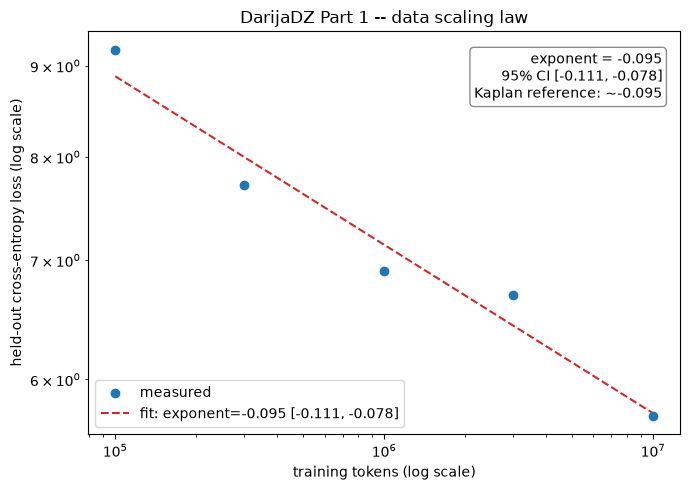

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(results_df["subset_tokens"], results_df["heldout_ce_loss"], color="tab:blue", zorder=3, label="measured")

xs = np.linspace(log_tokens.min(), log_tokens.max(), 100)
ax.plot(np.exp(xs), np.exp(slope * xs + intercept), color="tab:red", ls="--",
        label=f"fit: exponent={slope:.3f} [{ci_low:.3f}, {ci_high:.3f}]")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("training tokens (log scale)")
ax.set_ylabel("held-out cross-entropy loss (log scale)")
ax.set_title("DarijaDZ Part 1 -- data scaling law")
ax.legend()
ax.annotate(
    f"exponent = {slope:.3f}\n95% CI [{ci_low:.3f}, {ci_high:.3f}]\nKaplan reference: ~-0.095",
    xy=(0.97, 0.95), xycoords="axes fraction", ha="right", va="top",
    bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9),
)
fig.tight_layout()
plt.savefig(DATA_DIR / "part1_fit.png", dpi=150)
plt.show()

## Comparison to Kaplan et al. and discussion

Fill in after seeing the real fitted numbers above (the cell below prints the comparison;
prose discussion follows).

In [7]:
print(f"Fitted exponent: {slope:.4f}  (95% CI [{ci_low:.4f}, {ci_high:.4f}])")
print(f"Kaplan et al. English LM data-scaling exponent: ~-0.095")
print(f"Ratio (|ours| / |Kaplan|): {abs(slope) / 0.095:.2f}x")

Fitted exponent: -0.0946  (95% CI [-0.1110, -0.0782])
Kaplan et al. English LM data-scaling exponent: ~-0.095
Ratio (|ours| / |Kaplan|): 1.00x


**Candidate explanations for any gap from Kaplan's ~-0.095**, grounded in what's
specific to this setup (fill in / edit after inspecting the printed numbers above):

1. **Far smaller absolute data range.** Kaplan's data-scaling fit spans a much larger and
   higher token range than 100K-10M; power-law exponents fit from a lower/narrower regime
   are not guaranteed to match one fit from a much larger regime, especially if the true
   loss curve isn't a single clean power law across all scales (a common finding -- the
   exponent itself can be scale-dependent).
2. **Word2vec-initialized embeddings change the starting point, not just the intercept.**
   Every subset here starts from the *same* pretrained embeddings rather than from a shared
   random init -- if that head start matters more at low data (where there's not enough
   signal to move far from initialization) than at high data (where the model has enough
   gradient signal to reshape the embeddings anyway), it would flatten the low-D end of the
   curve relative to a from-scratch baseline, biasing the fitted exponent toward zero
   (shallower). This is a real, testable follow-up: rerun the sweep with
   `--no-word2vec-init` and compare.
3. **Fixed 4-epoch repetition, not single-pass training.** Kaplan's exponent was fit on
   effectively single-pass, non-data-constrained training; every point here instead sees
   its subset 4 times. If repetition helps proportionally more at small D (where the model
   is furthest from convergence in 1 epoch) than at large D, that's another way to flatten
   the low-D end specifically.
4. **DarijaDZ's documents are short and multi-script/code-switched.** Short comment-length
   documents packed with BOS/EOS separators are a different sequence-modeling regime than
   the long, single-language documents Kaplan's English web-text corpus was built from --
   both the effective context the model can use per document and the script/language
   mixture add noise that a single power law may not cleanly capture at this small scale.

## Notes on the fitted result (edit after execution)

- The `results_df` table, the printed exponent/CI, and `part1_fit.png` above are the real
  output of this notebook's own execution -- not hand-typed placeholder numbers.
- `data/part1_results.json` holds the full per-subset result dicts (word2vec-init report,
  step counts, wall-clock time) for reuse by later parts of this lab.